In [2]:
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris # For a standard pre-loaded dataset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print(tf.__version__)

# --- Step 1: Data Loading (Iris Dataset) ---
print("\n--- Step 1: Data Loading (Iris Dataset) ---")
iris = load_iris()
X, y = iris.data, iris.target

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


2.20.0

--- Step 1: Data Loading (Iris Dataset) ---


In [3]:
# --- Step 2: Data Analysis ---
print("\n--- Step 2: Data Analysis ---")
print(f"Shape of training features (X_train): {X_train.shape}")
print(f"Shape of training labels (y_train): {y_train.shape}")
print(f"Shape of test features (X_test): {X_test.shape}")
print(f"Shape of test labels (y_test): {y_test.shape}")

print("\nFeature names:")
print(iris.feature_names)

print("\nFirst 5 rows of training features:")
print(pd.DataFrame(X_train, columns=iris.feature_names).head())
print("\nSummary statistics of training features:")
print(pd.DataFrame(X_train, columns=iris.feature_names).describe())

print("\nDistribution of target labels (y_train):")
print(pd.Series(y_train).value_counts())


--- Step 2: Data Analysis ---
Shape of training features (X_train): (120, 4)
Shape of training labels (y_train): (120,)
Shape of test features (X_test): (30, 4)
Shape of test labels (y_test): (30,)

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

First 5 rows of training features:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                4.4               2.9                1.4               0.2
1                4.9               2.5                4.5               1.7
2                6.8               2.8                4.8               1.4
3                4.9               3.1                1.5               0.1
4                5.5               2.5                4.0               1.3

Summary statistics of training features:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         120.000000        120.000000          120.00000   
mean            5.841667          3.04

In [4]:
# --- Step 3: Data Preprocessing (Scaling Numerical Features) ---
print("\n--- Step 3: Data Preprocessing (Scaling Numerical Features) ---")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("First 5 rows of scaled training features:")
print(pd.DataFrame(X_train_scaled, columns=iris.feature_names).head())
print("Summary statistics of scaled training features:")
print(pd.DataFrame(X_train_scaled, columns=iris.feature_names).describe())

# Determine the number of classes for the output layer
num_classes = len(np.unique(y_train))
print(f"Number of output classes: {num_classes}")


--- Step 3: Data Preprocessing (Scaling Numerical Features) ---
First 5 rows of scaled training features:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0          -1.721568         -0.332101          -1.345722         -1.323276
1          -1.124492         -1.227655           0.414505          0.651763
2           1.144395         -0.555990           0.584850          0.256755
3          -1.124492          0.115676          -1.288941         -1.454945
4          -0.408002         -1.227655           0.130598          0.125086
Summary statistics of scaled training features:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count       1.200000e+02      1.200000e+02       1.200000e+02   
mean       -1.184238e-15     -1.998401e-15       4.958996e-16   
std         1.004193e+00      1.004193e+00       1.004193e+00   
min        -1.840983e+00     -2.347097e+00      -1.516067e+00   
25%        -8.856620e-01     -5.559895e-01      -1.232159e+00   

In [5]:
# --- Step 4: Model Building ---
print("\n--- Step 4: Model Building ---")
model = keras.Sequential([
    keras.layers.Dense   (32, activation='relu', input_shape=(X_train_scaled.shape[1],)), # Input layer
    keras.layers.Dense(16, activation='relu'),                                        # Hidden layer
    keras.layers.Dense(num_classes, activation='softmax')                             # Output layer for multi-class classification
])

model.summary()


--- Step 4: Model Building ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 739 (2.89 KB)

 Trainable params: 739 (2.89 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# --- Step 5: Model Compilation ---
print("\n--- Step 5: Model Compilation ---")
# For multi-class classification with integer labels, use 'sparse_categorical_crossentropy'
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


--- Step 5: Model Compilation ---


In [11]:
# --- Step 6: Model Training ---
print("\n--- Step 6: Model Training ---")
history = model.fit(X_train_scaled, y_train, epochs=20, batch_size=8, validation_split=0.2, verbose=1)




--- Step 6: Model Training ---
Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8854 - loss: 0.2618 - val_accuracy: 0.8333 - val_loss: 0.2910
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8854 - loss: 0.2525 - val_accuracy: 0.8750 - val_loss: 0.2762
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8854 - loss: 0.2440 - val_accuracy: 0.9167 - val_loss: 0.2596
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8854 - loss: 0.2358 - val_accuracy: 0.9167 - val_loss: 0.2483
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8854 - loss: 0.2282 - val_accuracy: 0.9167 - val_loss: 0.2451
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8854 - loss: 0.2203 - val_accuracy: 0.9167 - val_loss: 0.2320
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9167 - loss: 0.2133 - val_accuracy: 0.9167 - val_loss: 0.2073
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9271 - loss: 0

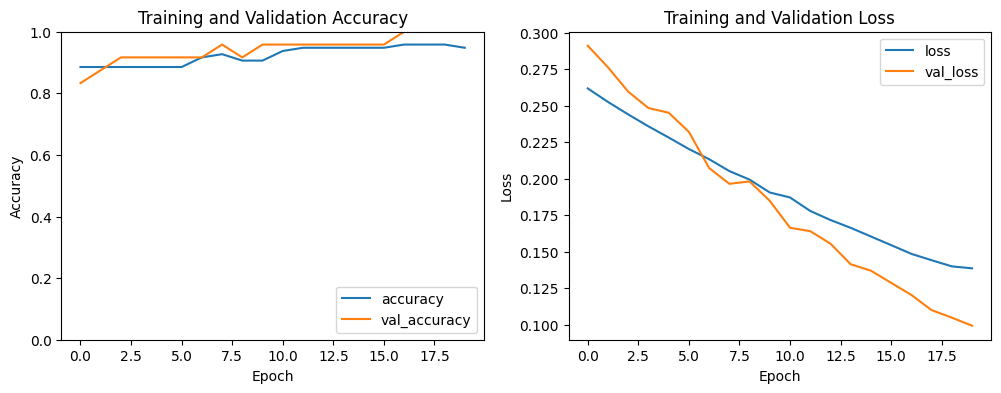

In [13]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [14]:
# --- Step 7: Model Evaluation ---
print("\n--- Step 7: Model Evaluation ---")
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=2)
print(f'\nTest loss: {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4f}')


--- Step 7: Model Evaluation ---
1/1 - 0s - 42ms/step - accuracy: 0.9333 - loss: 0.1742

Test loss: 0.1742
Test accuracy: 0.9333


In [15]:
# --- Step 8: Inference ---
print("\n--- Step 8: Inference ---")
# Make predictions on the first 5 test samples
predictions = model.predict(X_test_scaled[:5])
predicted_classes = np.argmax(predictions, axis=1)

print("\nPredictions for the first 5 test samples:")
for i in range(5):
    print(f"Sample {i+1}: Predicted Probabilities = {predictions[i]}, Predicted Class = {iris.target_names[predicted_classes[i]]} ({predicted_classes[i]}), Actual Class = {iris.target_names[y_test[i]]} ({y_test[i]})")



--- Step 8: Inference ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step

Predictions for the first 5 test samples:
Sample 1: Predicted Probabilities = [9.9852020e-01 1.4785486e-03 1.3595707e-06], Predicted Class = setosa (0), Actual Class = setosa (0)
Sample 2: Predicted Probabilities = [0.00295329 0.16127366 0.83577305], Predicted Class = virginica (2), Actual Class = virginica (2)
Sample 3: Predicted Probabilities = [0.02547136 0.9663418  0.00818696], Predicted Class = versicolor (1), Actual Class = versicolor (1)
Sample 4: Predicted Probabilities = [0.00927274 0.98357093 0.00715632], Predicted Class = versicolor (1), Actual Class = versicolor (1)
Sample 5: Predicted Probabilities = [9.993831e-01 6.160015e-04 8.583555e-07], Predicted Class = setosa (0), Actual Class = setosa (0)
